In [1]:
import ee
import geemap
import folium
import numpy as np

ee.Authenticate()
ee.Initialize(project='shrubland-coverage') # Replace with your project's name

In [2]:
RAP_veg_yearly_10m = ee.ImageCollection('projects/rap-data-365417/assets/vegetation-cover-10m')

In [3]:
print("Total images in collection:", RAP_veg_yearly_10m.size().getInfo())
first_img = RAP_veg_yearly_10m.first()
print("\nFirst image info (short):")
print(first_img.getInfo()['properties'].keys())

Total images in collection: 11864

First image info (short):
dict_keys(['system:time_start', 'year', 'system:footprint', 'x', 'y', 'utm_zone', 'system:index'])


In [4]:
years = (RAP_veg_yearly_10m
         .aggregate_array('year')
         .distinct()
         .sort()
         .getInfo())

print("Available years:", years)

Available years: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [5]:
band_names = first_img.bandNames().getInfo()
print("Band names:", band_names)

Band names: ['AFG', 'BGR', 'LTR', 'PFG', 'SHR', 'TRE']


In [6]:
year = 2025

images_2025 = (RAP_veg_yearly_10m
               .filter(ee.Filter.eq('year', year)))

print("Number of images for", year, ":", images_2025.size().getInfo())

# Inspect the IDs so you see what's there - Uncomment the print
ids_2025 = images_2025.aggregate_array('system:index').getInfo()
#print("Image IDs for", year, ":\n", ids_2025)

# Turn collection into a list and pick (Here we use index 35 because this image lands in California)
images_list = images_2025.toList(images_2025.size())
img_2025_alt = ee.Image(images_list.get(35))   

print("Chosen image ID:", img_2025_alt.get('system:index').getInfo())

# We specifically select the SHR band and rename it as shrub_cover
shrub_2025 = img_2025_alt.select('SHR').rename('shrub_cover')

Number of images for 2025 : 1483
Chosen image ID: 2025-10-500000-4300000


In [7]:
info = shrub_2025.getInfo()

print("Top-level keys:", info.keys())       

print("\nBands:")
for b in info['bands']:
    print(b)

print("\nProperties:")
for k, v in info['properties'].items():
    print(f"{k}: {v}")

Top-level keys: dict_keys(['type', 'bands', 'version', 'id', 'properties', 'uris'])

Bands:
{'id': 'shrub_cover', 'data_type': {'type': 'PixelType', 'precision': 'int', 'min': 0, 'max': 255}, 'dimensions': [7550, 7550], 'crs': 'EPSG:32610', 'crs_transform': [10, 0, 499750, 0, -10, 4375250]}

Properties:
system:time_start: 1735689600000
year: 2025
system:footprint: {'type': 'LinearRing', 'coordinates': [[-122.13283810966409, 38.843380266388124], [-122.13283706988321, 38.84339148991759], [-122.12443886634831, 39.52355853202705], [-122.12448574677258, 39.52360038952665], [-122.12452543480528, 39.523646380990535], [-122.12454458557568, 39.52364935383985], [-123.00285061834869, 39.52694585089132], [-123.00290440645226, 39.526909295570135], [-123.00296369362539, 39.52687818479562], [-123.00296635725118, 39.52686710329205], [-123.0029673024087, 39.52685586401701], [-123.00293886175571, 38.846610380903726], [-123.00289186162559, 38.846568894572606], [-123.00285190720135, 38.84652317631218], [-

In [8]:
# Visualization parameters
vis_params = {
    'min': 0,
    'max': 100,  # percent cover
    'palette': ['ffffff', 'c7e9c0', '74c476', '238b45', '00441b']
}

# Get map tile URL from EE
map_dict = shrub_2025.getMapId(vis_params)

m = folium.Map(location=[39, -120], zoom_start=6)

folium.TileLayer(
    tiles=map_dict['tile_fetcher'].url_format,
    attr='Google Earth Engine',
    overlay=True,
    name='Shrub cover 2025'
).add_to(m)

folium.LayerControl().add_to(m)

display(m)

In [9]:
# Tile bounds from the tile
min_lon = -123.0029673024087
max_lon = -122.12443886634831
min_lat =  38.8433024023722
max_lat =  39.52694585089132

km = 5.0

# Convert km to degrees (approx).
dlat = km / 111.32
dlon = km / (111.32 * np.cos(np.deg2rad(min_lat)))

# Build a SOUTH-WEST (lower-left) corner ROI that extends inward 
roi = ee.Geometry.Rectangle(
    [min_lon, min_lat, min_lon + dlon, min_lat + dlat],
    geodesic=False
)

# Extract array
img = shrub_2025.toFloat()
rect = img.sampleRectangle(region=roi, defaultValue=-9999)

arr = np.array(rect.get('shrub_cover').getInfo(), dtype=np.float32)
# Converting -9999 to nan
arr[arr == -9999] = np.nan

print("array:", arr.shape, arr.dtype)
print("min/max:", np.nanmin(arr), np.nanmax(arr))

array: (500, 501) float32
min/max: 0.0 76.0


Array shape: (500, 501)
Total pixel count: 250500
Valid pixel count: 231500
NaN pixel count: 19000

Descriptive statistics:
         shrub_cover
count  231500.000000
mean       12.065974
std        14.223836
min         0.000000
25%         2.000000
50%         6.000000
75%        16.000000
max        76.000000

Quantiles:
      shrub_cover
0.01          0.0
0.05          1.0
0.10          1.0
0.25          2.0
0.50          6.0
0.75         16.0
0.90         36.0
0.95         44.0
0.99         56.0

Cover summary:
Zero-cover pixels     : 9598
Positive-cover pixels : 221902
Zero-cover ratio (%)  : 4.15
Positive-cover ratio (%): 95.85


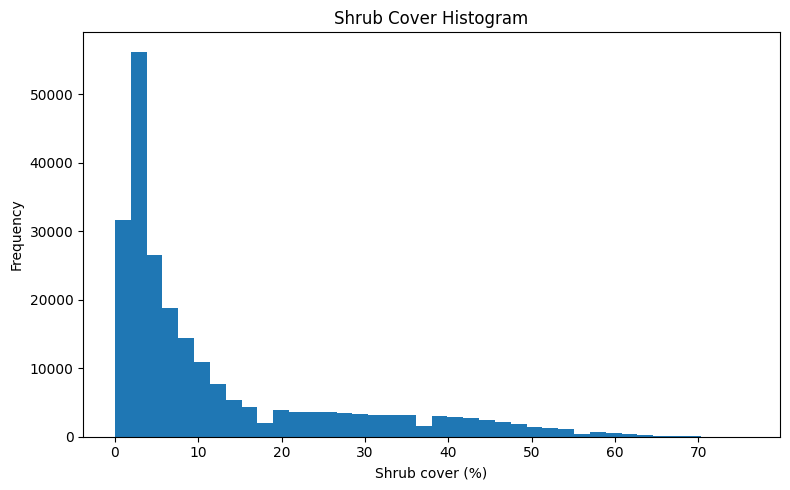

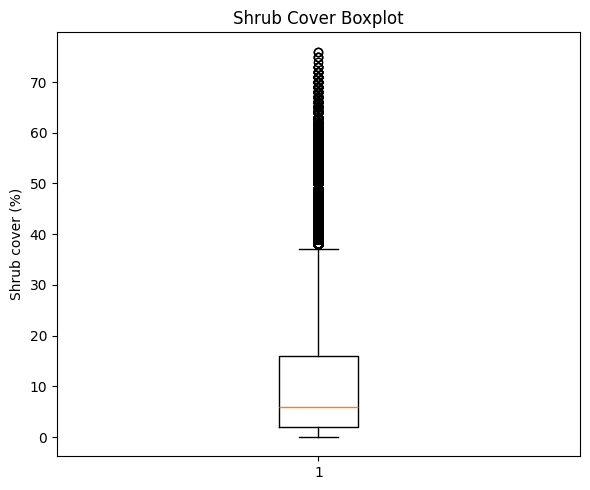

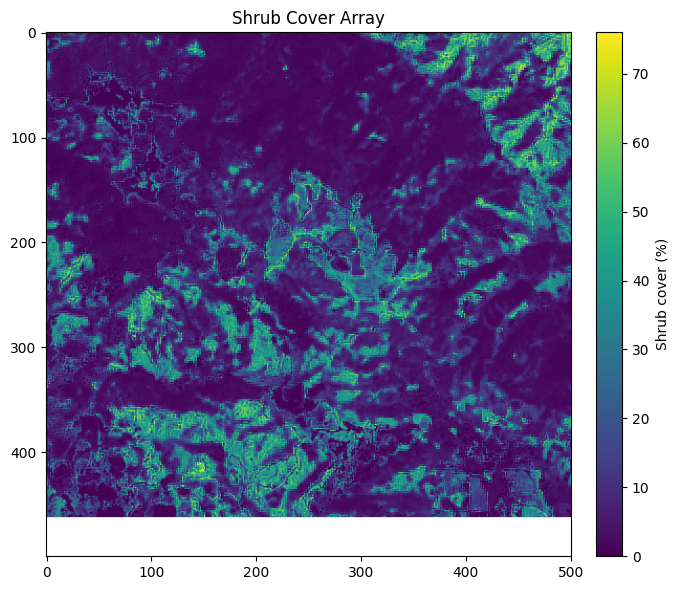

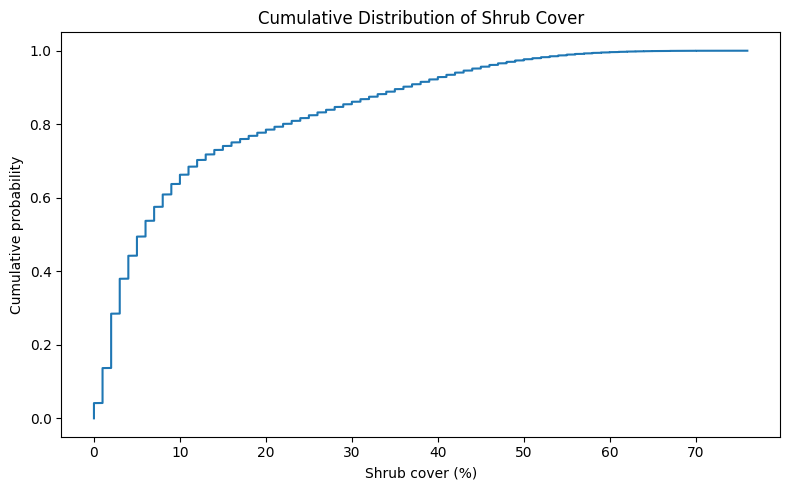


Cover class counts:
cover_class
0           9598
0-5       104842
5-10       38956
10-25      37441
25-50      35274
50-75       5387
75-100         2
Name: count, dtype: int64


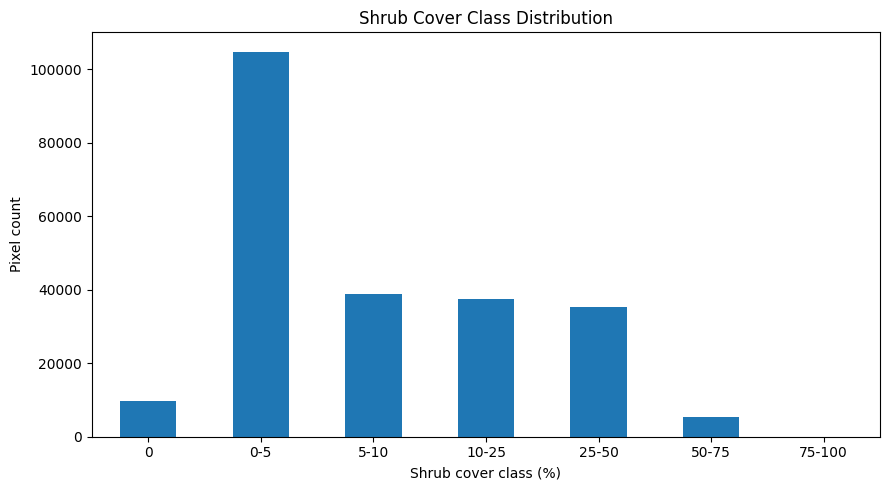

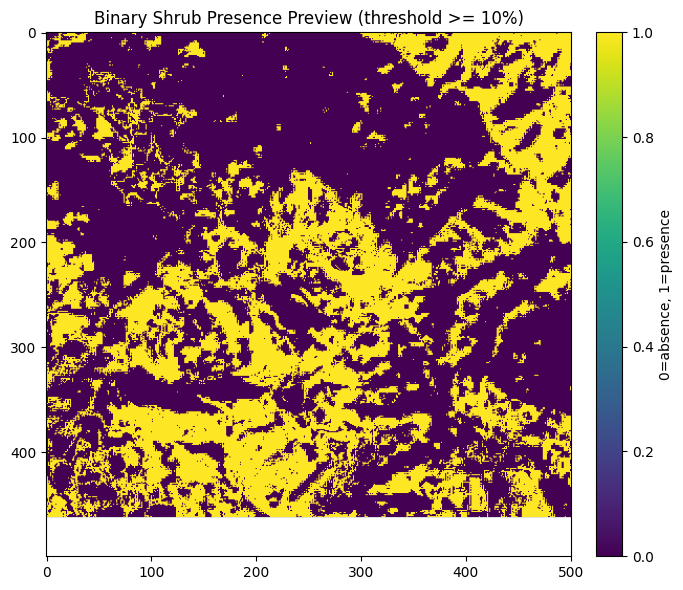

In [11]:
# =========================================================
# MODULE 3 - STATISTICAL SUMMARY + PLOTS FOR SHRUB COVER
# (Append this cell after the existing code)
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1) Flatten array + valid pixels
# ---------------------------
arr_flat = arr.ravel()
valid_mask = np.isfinite(arr_flat)

df = pd.DataFrame({
    "shrub_cover": arr_flat[valid_mask]
})

print("Array shape:", arr.shape)
print("Total pixel count:", arr.size)
print("Valid pixel count:", len(df))
print("NaN pixel count:", np.isnan(arr).sum())

# ---------------------------
# 2) Basic descriptive statistics
# ---------------------------
print("\nDescriptive statistics:")
print(df.describe())

print("\nQuantiles:")
print(df.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

# ---------------------------
# 3) Zero-cover / positive-cover summary
# ---------------------------
zero_count = (df["shrub_cover"] == 0).sum()
positive_count = (df["shrub_cover"] > 0).sum()

print("\nCover summary:")
print(f"Zero-cover pixels     : {zero_count}")
print(f"Positive-cover pixels : {positive_count}")
print(f"Zero-cover ratio (%)  : {100 * zero_count / len(df):.2f}")
print(f"Positive-cover ratio (%): {100 * positive_count / len(df):.2f}")

# ---------------------------
# 4) Histogram
# ---------------------------
plt.figure(figsize=(8, 5))
plt.hist(df["shrub_cover"], bins=40)
plt.title("Shrub Cover Histogram")
plt.xlabel("Shrub cover (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ---------------------------
# 5) Boxplot
# ---------------------------
plt.figure(figsize=(6, 5))
plt.boxplot(df["shrub_cover"].dropna(), vert=True)
plt.title("Shrub Cover Boxplot")
plt.ylabel("Shrub cover (%)")
plt.tight_layout()
plt.show()

# ---------------------------
# 6) Spatial map of shrub cover array
# ---------------------------
plt.figure(figsize=(7, 6))
im = plt.imshow(arr)
plt.title("Shrub Cover Array")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Shrub cover (%)")
plt.tight_layout()
plt.show()

# ---------------------------
# 7) Cumulative distribution
# ---------------------------
sorted_vals = np.sort(df["shrub_cover"].values)
cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)

plt.figure(figsize=(8, 5))
plt.plot(sorted_vals, cdf)
plt.title("Cumulative Distribution of Shrub Cover")
plt.xlabel("Shrub cover (%)")
plt.ylabel("Cumulative probability")
plt.tight_layout()
plt.show()

# ---------------------------
# 8) Cover classes
# ---------------------------
bins = [-0.1, 0, 5, 10, 25, 50, 75, 100]
labels = ["0", "0-5", "5-10", "10-25", "25-50", "50-75", "75-100"]

df["cover_class"] = pd.cut(df["shrub_cover"], bins=bins, labels=labels, include_lowest=True)
class_counts = df["cover_class"].value_counts().sort_index()

print("\nCover class counts:")
print(class_counts)

plt.figure(figsize=(9, 5))
class_counts.plot(kind="bar")
plt.title("Shrub Cover Class Distribution")
plt.xlabel("Shrub cover class (%)")
plt.ylabel("Pixel count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------
# 9) Optional binary preview map
# Example threshold = 10%
# ---------------------------
threshold = 10
binary_arr = np.where(np.isfinite(arr), (arr >= threshold).astype(np.uint8), np.nan)

plt.figure(figsize=(7, 6))
plt.imshow(binary_arr)
plt.title(f"Binary Shrub Presence Preview (threshold >= {threshold}%)")
plt.colorbar(fraction=0.046, pad=0.04, label="0=absence, 1=presence")
plt.tight_layout()
plt.show()

In [12]:
# ALS-TLS Data Demo

In [13]:

import requests
import laspy
from io import BytesIO

# 1. We set the URL for ALS file
als_url = "https://wifire-data.sdsc.edu/nc/public.php/dav/files/ucca-dl-bliss/ALS/USGS_LPC_CA_SierraNevada_B22_10SGJ5019.laz"

# 2. We fetch ALS file content
response_als = requests.get(als_url)

# 3. We load the ALS data into memory
als_buffer = BytesIO(response_als.content)

# 4. We open the file using laspy, and print the format and number of points.
with laspy.open(als_buffer) as als_file:
    print(f"ALS Point Format: {als_file.header.point_format}")
    print(f"ALS Number of Points: {als_file.header.point_count}")

# 5. We also open the file for next tasks
    als_points = als_file.read()

ALS Point Format: <PointFormat(6, 0 bytes of extra dims)>
ALS Number of Points: 27865339


In [14]:
# We need to convert the object into a list for proper display
list(als_points.point_format.dimension_names)

['X',
 'Y',
 'Z',
 'intensity',
 'return_number',
 'number_of_returns',
 'synthetic',
 'key_point',
 'withheld',
 'overlap',
 'scanner_channel',
 'scan_direction_flag',
 'edge_of_flight_line',
 'classification',
 'user_data',
 'scan_angle',
 'point_source_id',
 'gps_time']

In [15]:
# Save XYZ as np arrays and print the first 5 points consecutively. 
x_als, y_als, z_als = als_points.x, als_points.y, als_points.z
print(f"First 5 ALS points (x, y, z): {list(zip(x_als[:5], y_als[:5], z_als[:5]))}")


First 5 ALS points (x, y, z): [(np.float64(750990.38), np.float64(4319999.98), np.float64(2016.23)), (np.float64(750999.77), np.float64(4319999.79), np.float64(2018.39)), (np.float64(750966.09), np.float64(4319999.98), np.float64(2026.18)), (np.float64(750964.72), np.float64(4319999.97), np.float64(2023.51)), (np.float64(750966.17), np.float64(4319999.96), np.float64(2025.0))]


In [16]:
import sys
!{sys.executable} -m pip install -U nbformat ipykernel
import plotly.graph_objects as go

subset_size = 50000  # You can change this value, but this sample should be enough for our visualization purposes.

# 2. We create an interactive 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_als[:subset_size],
    y=y_als[:subset_size],
    z=z_als[:subset_size],
    mode='markers',
    marker=dict(
        size=2,                     
        color=z_als[:subset_size],   # Color points by height (just to make it look nicer :D)
        colorscale='Viridis',        
        opacity=0.8                  
    )
)])

# 3. We add a few details and show the figure
fig.update_layout(
    title="Airborne Laser Scanning (ALS) Point Cloud",
    scene=dict(
        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)"
    ),
    margin=dict(l=0, r=0, b=0, t=40)  
)

fig.show()

In [17]:
import requests
from pathlib import Path
import subprocess

ptx_url = "https://wifire-data.sdsc.edu/nc/public.php/dav/files/ucca-dl-bliss/original_TLS/CAAEU_0001_20250722_1.ptx"

save_dir = Path("/Users/berkayersus/Desktop/maki")
save_dir.mkdir(parents=True, exist_ok=True)

ptx_file = save_dir / "input.ptx"
laz_file = save_dir / "output.laz"

# Download
response = requests.get(ptx_url)
response.raise_for_status()

with ptx_file.open("wb") as f:
    f.write(response.content)

print(f"Downloaded PTX file: {ptx_file}")

# Convert with PDAL
pdal_command = ["pdal", "translate", str(ptx_file), str(laz_file)]
result = subprocess.run(pdal_command, capture_output=True, text=True)

if result.returncode == 0:
    print(f"Converted {ptx_file} to {laz_file}")
else:
    print("STDOUT:", result.stdout)
    print("STDERR:", result.stderr)
    raise RuntimeError(f"PDAL translation error: {result.stderr}")

# Delete original PTX
ptx_file.unlink()
print(f"Deleted original PTX file: {ptx_file}")

Downloaded PTX file: /Users/berkayersus/Desktop/maki/input.ptx
Converted /Users/berkayersus/Desktop/maki/input.ptx to /Users/berkayersus/Desktop/maki/output.laz
Deleted original PTX file: /Users/berkayersus/Desktop/maki/input.ptx


In [18]:
# Read the .las file using Laspy
with laspy.open(laz_file) as tls_file:
    print(f"Point Format: {tls_file.header.point_format}")
    print(f"Number of Points: {tls_file.header.point_count}")

    # Read all points from the LAZ file
    tls_points = tls_file.read()
    list(tls_points.point_format.dimension_names)

# Now we can remove the .laz file
laz_file.unlink()
print(f"Deleted original LAZ file: {laz_file}")

Point Format: <PointFormat(7, 0 bytes of extra dims)>
Number of Points: 10581637
Deleted original LAZ file: /Users/berkayersus/Desktop/maki/output.laz


In [19]:
# We recycle code again :)
list(tls_points.point_format.dimension_names)

['X',
 'Y',
 'Z',
 'intensity',
 'return_number',
 'number_of_returns',
 'synthetic',
 'key_point',
 'withheld',
 'overlap',
 'scanner_channel',
 'scan_direction_flag',
 'edge_of_flight_line',
 'classification',
 'user_data',
 'scan_angle',
 'point_source_id',
 'gps_time',
 'red',
 'green',
 'blue']

In [20]:
r_tls, g_tls, b_tls = tls_points.red, tls_points.green, tls_points.blue
print(f"\nFirst 5 points (R, G, B): {list(zip(r_tls[:5], g_tls[:5], b_tls[:5]))}")


First 5 points (R, G, B): [(np.uint16(67), np.uint16(72), np.uint16(78)), (np.uint16(61), np.uint16(66), np.uint16(70)), (np.uint16(59), np.uint16(64), np.uint16(70)), (np.uint16(66), np.uint16(70), np.uint16(79)), (np.uint16(70), np.uint16(74), np.uint16(83))]


In [21]:
import numpy as np
import requests
from pathlib import Path

ptx_url = "https://wifire-data.sdsc.edu/nc/public.php/dav/files/ucca-dl-bliss/original_TLS/CAAEU_0001_20250722_1.ptx"

save_dir = Path("/Users/berkayersus/Desktop/maki")
save_dir.mkdir(parents=True, exist_ok=True)

ptx_file = save_dir / "input.ptx"

response = requests.get(ptx_url)
response.raise_for_status()

with ptx_file.open("wb") as f:
    f.write(response.content)

print("Saved:", ptx_file)

n_header = 10  # header satır sayısı

tls_ptx = np.loadtxt(ptx_file, skiprows=n_header)
tls_ptx = tls_ptx[~np.all(tls_ptx == 0, axis=1)]

print(tls_ptx.shape)

ptx_file.unlink()
print("Deleted:", ptx_file)

Saved: /Users/berkayersus/Desktop/maki/input.ptx
(10581637, 7)
Deleted: /Users/berkayersus/Desktop/maki/input.ptx


In [22]:
import numpy as np

subset_size = 100000  # Number of points to sample

# We generate a set of random points
random_indices = np.random.choice(len(tls_points.x), size=subset_size, replace=False)

# Use the random indices to select points
fig = go.Figure(data=[go.Scatter3d(
    x=tls_points.x[random_indices],
    y=tls_points.y[random_indices],
    z=tls_points.z[random_indices],
    mode='markers',
    marker=dict(
        size=2,
        color=r_tls[random_indices],  # Let's use red as the scale for our colors
        colorscale='Reds',
        opacity=0.8
    )
)])

fig.update_layout(
    title="3D Point Cloud Visualization (LAZ Data)",
    scene=dict(
        xaxis_title="X (m)",
        yaxis_title="Y (m)",
        zaxis_title="Z (m)"
    ),
    margin=dict(l=0, r=0, b=0, t=40)  
)

# Display the plot
fig.show()

In [23]:
from dask.system import cpu_count

cores = cpu_count()
print(f"Number of CPU cores available: {cores}")

Number of CPU cores available: 8


In [24]:
import dask.array as da

# 1. First, we will transform our features into Dask arrays
x_coords = da.from_array(als_points.x, chunks=10000)
y_coords = da.from_array(als_points.y, chunks=10000)
z_coords = da.from_array(als_points.z, chunks=10000)
intensity = da.from_array(als_points.intensity, chunks=10000)
classification = da.from_array(als_points.classification, chunks=10000)  # This is the target variable

# 2. Now, we define sample size and generate random indices
sample_size = 2_000_000  # For this example, we will only use a sample of 2,000,000 points, otherwise training time would be more extensive.
total_size = x_coords.shape[0]
random_indices_np = np.random.choice(total_size, size=sample_size, replace=False)
random_indices = da.from_array(random_indices_np, chunks=10000).compute()

# 3. Now we convert Dask arrays to NumPy arrays for selected samples
x_sample = x_coords.compute()[random_indices]
y_sample = y_coords.compute()[random_indices]
z_sample = z_coords.compute()[random_indices]
intensity_sample = intensity.compute()[random_indices]
classification_sample = classification.compute()[random_indices]

# 4. We stack all features in a single array for easier processing
features = np.stack([x_sample, y_sample, z_sample, intensity_sample], axis=1)

In [25]:
from collections import Counter

class_counts = Counter(als_points.classification)
total_points = sum(class_counts.values())

for cls, count in class_counts.items():
    percentage = (count / total_points) * 100
    print(f"Class {cls}: {percentage:.2f}%")

Class 2: 15.40%
Class 1: 84.35%
Class 7: 0.22%
Class 18: 0.03%


In [26]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# 5. We perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features, classification_sample, stratify=classification_sample, test_size=0.2, random_state=42
)

# 6. Then, we map non-contiguous class labels to contiguous ones - This is a required step for XGBoost
label_encoder = LabelEncoder()
y_train_mapped = label_encoder.fit_transform(y_train)
y_test_mapped = label_encoder.transform(y_test)

# 7. Now, we apply SMOTE to oversample minority classes, otherwise our model will struggle to learn
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train_mapped)

In [27]:
# FYI This cell will take around 3 min to run
from xgboost import XGBClassifier

# 8. With the data ready, we initialize and train the XGBoost model
model = XGBClassifier(
    objective="multi:softmax",  # Multi-class classification
    num_class=len(np.unique(y_resampled)),  # Number of classes
    random_state=42,
    eval_metric="mlogloss"
)
model.fit(X_resampled, y_resampled)

# 9. After training, we predict on the test set
y_pred_mapped = model.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_mapped) # We return the original labels to our classes

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 10. Now we have to evaluate the model
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 65.36%

Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.63      0.77    337432
           2       0.37      0.77      0.50     61546
           7       0.01      0.63      0.02       907
          18       0.05      0.88      0.10       115

    accuracy                           0.65    400000
   macro avg       0.35      0.73      0.35    400000
weighted avg       0.89      0.65      0.73    400000

Confusion Matrix:
[[213553  81242  40752   1885]
 [  2775  47207  11547     17]
 [    81    256    570      0]
 [    12      1      1    101]]



==================== GENEL METRİKLER ====================
Accuracy            : 0.6536
Balanced Accuracy   : 0.7267
Macro Precision     : 0.3537
Macro Recall        : 0.7267
Macro F1            : 0.3460
Weighted Precision  : 0.8889
Weighted Recall     : 0.6536
Weighted F1         : 0.7270
Cohen's Kappa       : 0.2984

================ CLASSIFICATION REPORT =================
              precision    recall  f1-score   support

           1       0.99      0.63      0.77    337432
           2       0.37      0.77      0.50     61546
           7       0.01      0.63      0.02       907
          18       0.05      0.88      0.10       115

    accuracy                           0.65    400000
   macro avg       0.35      0.73      0.35    400000
weighted avg       0.89      0.65      0.73    400000


================ CLASS-WISE METRİKLER =================
   Class  Precision    Recall        F1  Support  Per-class Accuracy
0      1   0.986748  0.632877  0.771154   337432            0

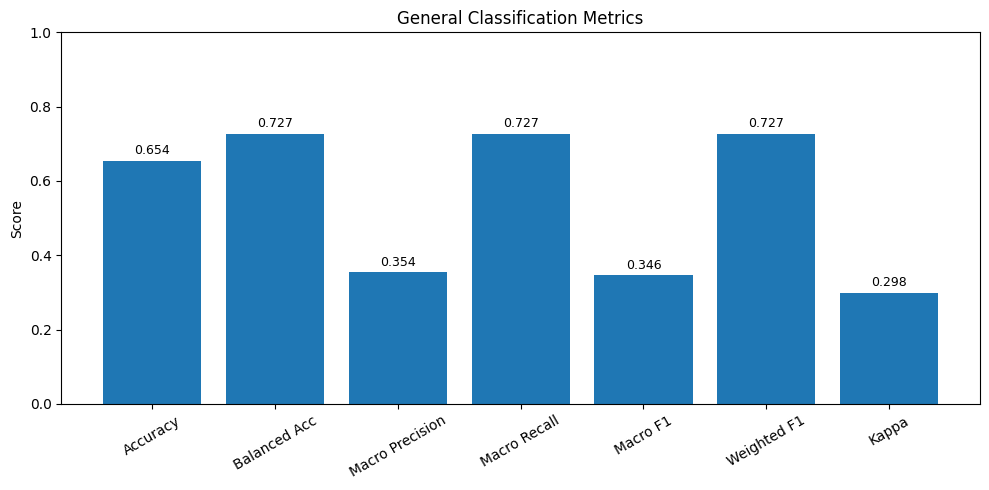

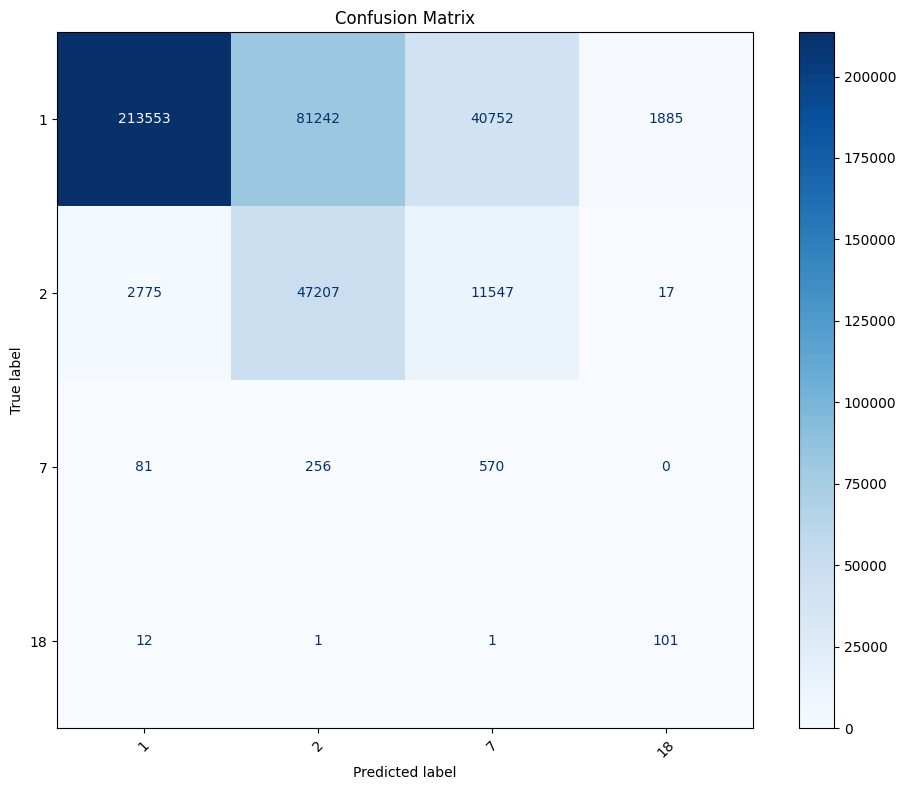

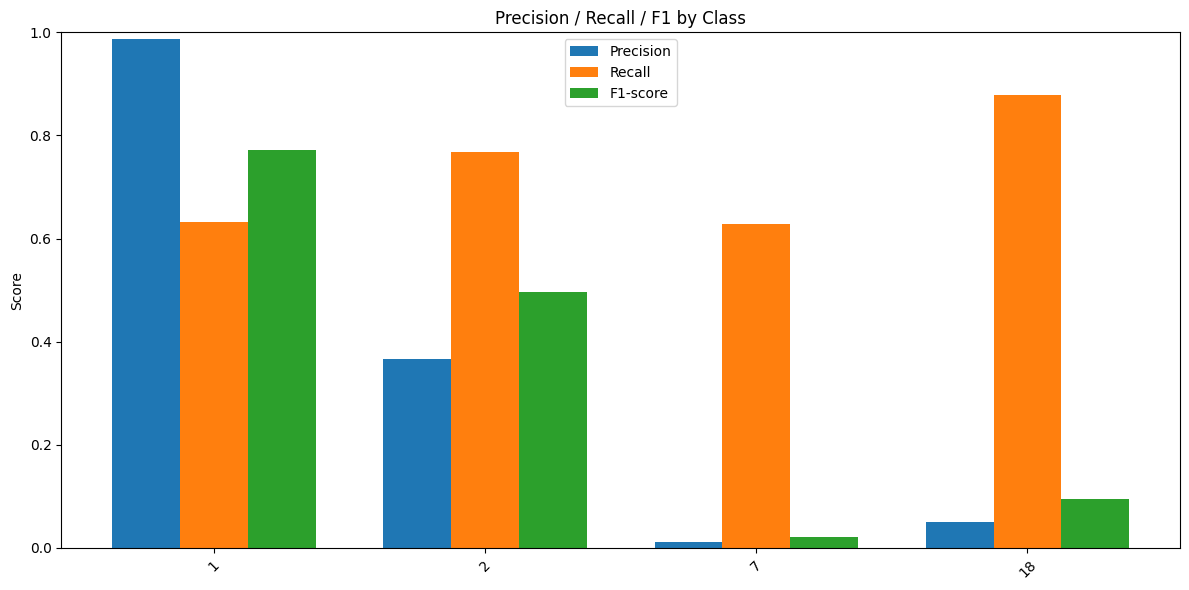

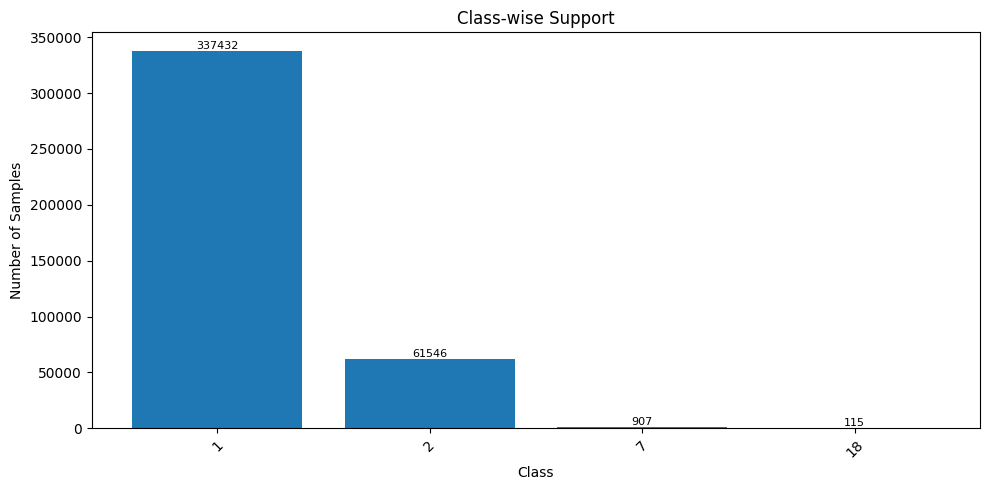

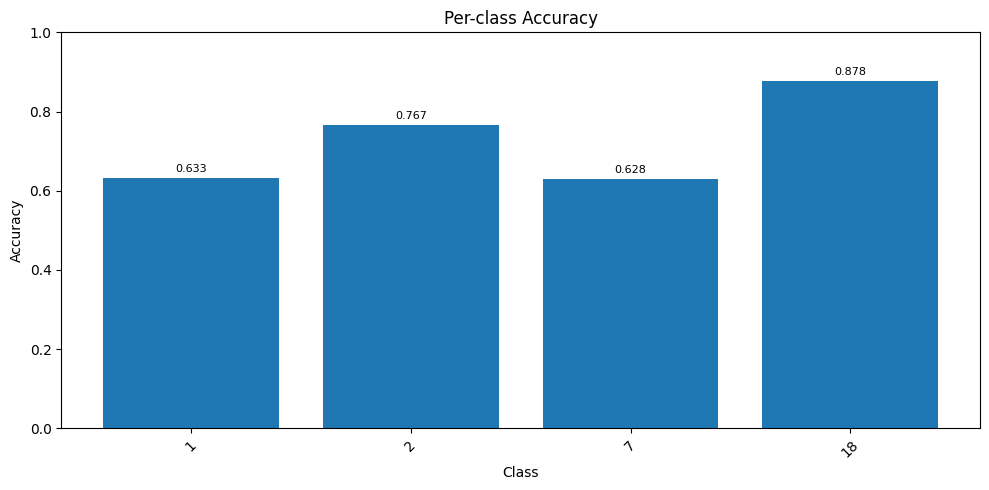

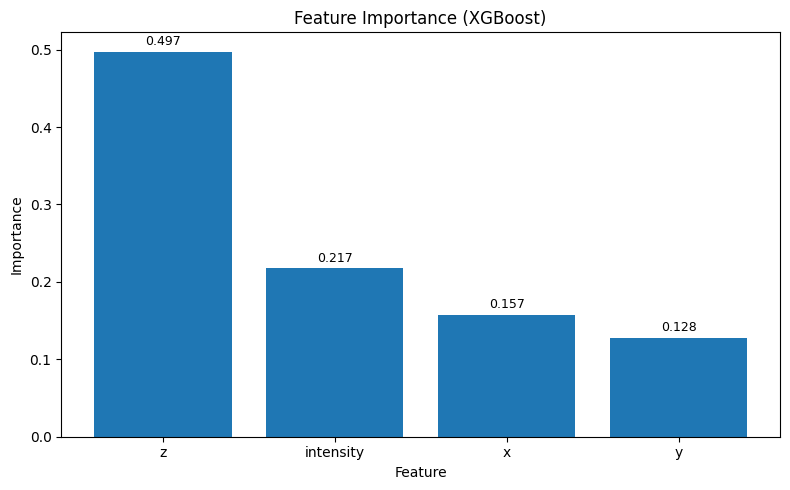

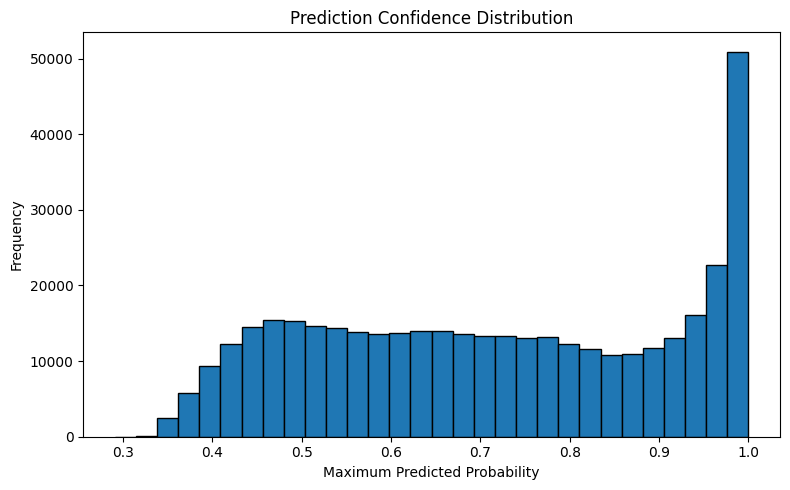

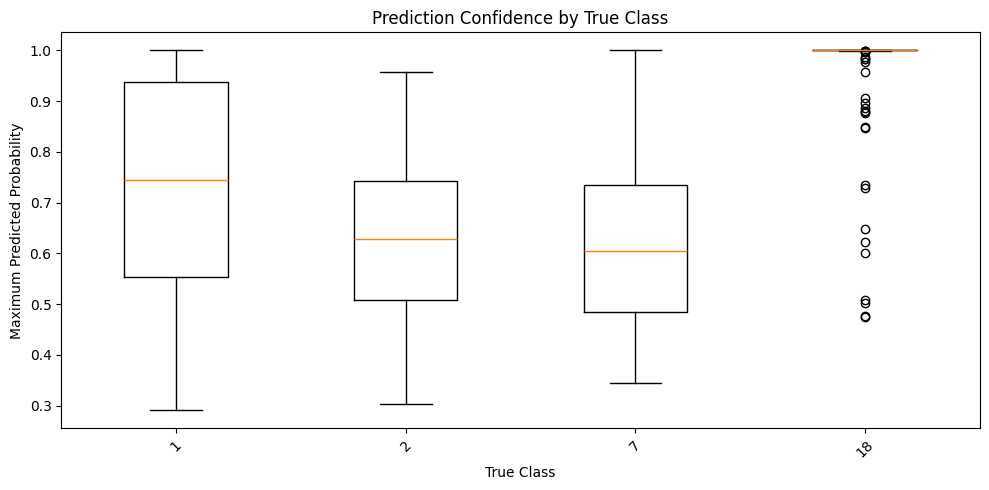

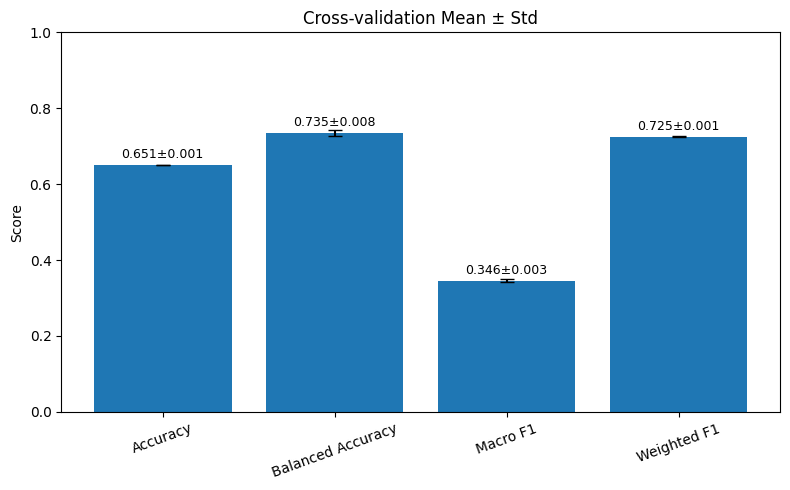

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    cohen_kappa_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# =========================================================

# =========================================================


y_pred_mapped = model.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_mapped)


try:
    y_proba = model.predict_proba(X_test)
except Exception:
    y_proba = None
    print("Warning: predict_proba alınamadı. Modeli multi:softprob ile eğitmen önerilir.")

class_labels = label_encoder.classes_

# =========================================================
# 
# =========================================================

accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test, y_pred, average='macro', zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test, y_pred, average='weighted', zero_division=0
)

print("\n==================== GENEL METRİKLER ====================")
print(f"Accuracy            : {accuracy:.4f}")
print(f"Balanced Accuracy   : {balanced_acc:.4f}")
print(f"Macro Precision     : {precision_macro:.4f}")
print(f"Macro Recall        : {recall_macro:.4f}")
print(f"Macro F1            : {f1_macro:.4f}")
print(f"Weighted Precision  : {precision_weighted:.4f}")
print(f"Weighted Recall     : {recall_weighted:.4f}")
print(f"Weighted F1         : {f1_weighted:.4f}")
print(f"Cohen's Kappa       : {kappa:.4f}")

print("\n================ CLASSIFICATION REPORT =================")
print(classification_report(y_test, y_pred, zero_division=0))

# =========================================================
#
# =========================================================

precisions, recalls, f1s, supports = precision_recall_fscore_support(
    y_test, y_pred, labels=class_labels, zero_division=0
)

cm = confusion_matrix(y_test, y_pred, labels=class_labels)

# Per-class accuracy = her sınıf için doğru tahmin / o sınıfın gerçek toplamı
per_class_accuracy = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)

metrics_df = pd.DataFrame({
    "Class": class_labels,
    "Precision": precisions,
    "Recall": recalls,
    "F1": f1s,
    "Support": supports,
    "Per-class Accuracy": per_class_accuracy
})

print("\n================ CLASS-WISE METRİKLER =================")
print(metrics_df)

# =========================================================
# 4
# =========================================================

feature_names = ["x", "y", "z", "intensity"]

if hasattr(model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)
else:
    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": [0] * len(feature_names)
    })

print("\n================ FEATURE IMPORTANCE =================")
print(feature_importance_df)

# =========================================================
#
# =========================================================

if y_proba is not None:
    max_prob = np.max(y_proba, axis=1)   # her nokta için en yüksek sınıf olasılığı
else:
    max_prob = None

# =========================================================
# 6) CROSS-VALIDATION (mean ± std)
# =========================================================
# Not: Veri sızıntısını azaltmak için SMOTE, CV pipeline içine alındı.
# Burada classification_sample kullanılıyor çünkü başlangıçta ondan train/test üretilmişti.

cv_encoder = LabelEncoder()
y_all_encoded = cv_encoder.fit_transform(classification_sample)

cv_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y_all_encoded)),
        random_state=42,
        eval_metric="mlogloss"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

cv_results = cross_validate(
    cv_pipeline,
    features,
    y_all_encoded,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1"],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_balanced_accuracy"].mean(),
        cv_results["test_f1_macro"].mean(),
        cv_results["test_f1_weighted"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_balanced_accuracy"].std(),
        cv_results["test_f1_macro"].std(),
        cv_results["test_f1_weighted"].std()
    ]
})

print("\n================ CROSS-VALIDATION SUMMARY ================")
print(cv_summary)

# =========================================================

# =========================================================

# ---------- Plot 1: Genel metrikler ----------
general_metrics_names = [
    "Accuracy", "Balanced Acc", "Macro Precision",
    "Macro Recall", "Macro F1", "Weighted F1", "Kappa"
]
general_metrics_values = [
    accuracy, balanced_acc, precision_macro,
    recall_macro, f1_macro, f1_weighted, kappa
]

plt.figure(figsize=(10, 5))
bars = plt.bar(general_metrics_names, general_metrics_values)
plt.ylim(0, 1)
plt.title("General Classification Metrics")
plt.ylabel("Score")
plt.xticks(rotation=30)

for bar, val in zip(bars, general_metrics_values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


# ---------- Plot 2: Confusion Matrix ----------
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


# ---------- Plot 3: Precision / Recall / F1 by Class ----------
x = np.arange(len(class_labels))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, precisions, width=width, label="Precision")
plt.bar(x, recalls, width=width, label="Recall")
plt.bar(x + width, f1s, width=width, label="F1-score")

plt.xticks(x, class_labels, rotation=45)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Precision / Recall / F1 by Class")
plt.legend()
plt.tight_layout()
plt.show()


# ---------- Plot 4: Class-wise Support ----------
plt.figure(figsize=(10, 5))
bars = plt.bar(metrics_df["Class"].astype(str), metrics_df["Support"])
plt.title("Class-wise Support")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

for bar, val in zip(bars, metrics_df["Support"]):
    plt.text(bar.get_x() + bar.get_width()/2, val, f"{int(val)}",
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


# ---------- Plot 5: Per-class Accuracy ----------
plt.figure(figsize=(10, 5))
bars = plt.bar(metrics_df["Class"].astype(str), metrics_df["Per-class Accuracy"])
plt.ylim(0, 1)
plt.title("Per-class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

for bar, val in zip(bars, metrics_df["Per-class Accuracy"]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


# ---------- Plot 6: Feature Importance ----------
plt.figure(figsize=(8, 5))
bars = plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Feature")
plt.ylabel("Importance")

for bar, val in zip(bars, feature_importance_df["Importance"]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.3f}",
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


# ---------- Plot 7: Prediction Confidence Histogram ----------
if max_prob is not None:
    plt.figure(figsize=(8, 5))
    plt.hist(max_prob, bins=30, edgecolor="black")
    plt.title("Prediction Confidence Distribution")
    plt.xlabel("Maximum Predicted Probability")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


# ---------- Plot 8: Confidence by True Class ----------
if max_prob is not None:
    plt.figure(figsize=(10, 5))
    class_order = metrics_df["Class"].astype(str).tolist()

    conf_data = []
    for c in class_labels:
        conf_data.append(max_prob[y_test == c])

    plt.boxplot(conf_data, tick_labels=class_order)
    plt.title("Prediction Confidence by True Class")
    plt.xlabel("True Class")
    plt.ylabel("Maximum Predicted Probability")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# ---------- Plot 9: Cross-validation mean ± std ----------
plt.figure(figsize=(8, 5))
bars = plt.bar(cv_summary["Metric"], cv_summary["Mean"], yerr=cv_summary["Std"], capsize=5)
plt.ylim(0, 1)
plt.title("Cross-validation Mean ± Std")
plt.ylabel("Score")
plt.xticks(rotation=20)

for bar, mean_val, std_val in zip(bars, cv_summary["Mean"], cv_summary["Std"]):
    plt.text(bar.get_x() + bar.get_width()/2, mean_val + 0.01,
             f"{mean_val:.3f}±{std_val:.3f}",
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()